## Check which Epoch to stop training at

In [7]:
from os import scandir
# Open all epoch files for result for ERM
# For each file count number of wrong predictions
# Plot wrong predictions over epochs
# choose based on percentage of wrong predictions
root = "MNISTCIFAR"
results = dict()
for f in scandir(root):
    if "erm" in f.path:
        spur = f.path.split("_")[-1]
        model = f.path.split("/")[-1]
        results[model] = dict()
        # get all data
        for xls in scandir(f.path):
            seed = xls.path.split("_")[-1]
            if "train" in xls.path:
                print(xls)

MNISTCIFAR/erm_0.0/model_outputs_111
MNISTCIFAR/erm_0.0/model_outputs_222
MNISTCIFAR/erm_0.0/model_outputs_333
MNISTCIFAR/erm_0.25/model_outputs_111
MNISTCIFAR/erm_0.25/model_outputs_222
MNISTCIFAR/erm_0.25/model_outputs_333
MNISTCIFAR/erm_0.5/model_outputs_111
MNISTCIFAR/erm_0.5/model_outputs_222
MNISTCIFAR/erm_0.5/model_outputs_333
MNISTCIFAR/erm_0.75/model_outputs_111
MNISTCIFAR/erm_0.75/model_outputs_222
MNISTCIFAR/erm_0.75/model_outputs_333
MNISTCIFAR/erm_0.9/model_outputs_111
MNISTCIFAR/erm_0.9/model_outputs_222
MNISTCIFAR/erm_0.9/model_outputs_333


In [43]:
import pandas as pd
import os
import numpy as np
from tqdm.notebook import tqdm
dataset ="MNISTCIFAR"
exps = []
for f in scandir(dataset):
    if "erm" in f.path:
        for f1 in scandir(f.path):
            for f2 in scandir(f1.path):
                if "output_train" in f2.path:
                    exps.append(f2.path)

def extract_data(path):
    r = dict()
    r['dataset'] = path.split("/")[0]
    r['method'] = "_".join(path.split("/")[1].split("_")[:-1])
    r['corr']= path.split("/")[1].split("_")[-1]
    r['seed'] = path.split("/")[2].split("_")[-1]
    r['epoch'] = path.split("/")[-1].split("_")[-1].replace(".csv","")
    r['split'] = path.split("/")[-1].split("_")[1]
    return r
                

#
   
# Create
results  = pd.DataFrame()
for f in tqdm(exps):
    r = extract_data(f)
    data_dir = "/".join(f.split("/")[:-1])
    train_df = pd.read_csv(os.path.join(data_dir, f"output_train_epoch_{r['epoch']}.csv"))
    train_df = train_df.sort_values(f"indices_None_epoch_{r['epoch']}_val")
    train_df["wrong_1_times"] = (1.0 * (train_df[f"y_pred_None_epoch_{r['epoch']}_val"] != train_df[f"y_true_None_epoch_{r['epoch']}_val"])).apply(np.int64)
    r['wrong'] = np.sum(train_df['wrong_1_times'])
    results = results.append(r,ignore_index=True)

results.to_csv(f'erm_wrong_train_samples.csv', index=False)

  0%|          | 0/75015 [00:00<?, ?it/s]

In [39]:
results = results.append(r, ignore_index=True)

In [44]:
results

,dataset,method,corr,seed,epoch,split,wrong
0,MNISTCIFAR,erm,0.0,111,139,train,2845.0
1,MNISTCIFAR,erm,0.0,111,659,train,2167.0
2,MNISTCIFAR,erm,0.0,111,736,train,2101.0
3,MNISTCIFAR,erm,0.0,111,809,train,2054.0
4,MNISTCIFAR,erm,0.0,111,1122,train,1911.0
...,...,...,...,...,...,...,...
75010,MNISTCIFAR,erm,0.9,333,1288,train,530.0
75011,MNISTCIFAR,erm,0.9,333,636,train,538.0
75012,MNISTCIFAR,erm,0.9,333,4762,train,396.0
75013,MNISTCIFAR,erm,0.9,333,3957,train,425.0


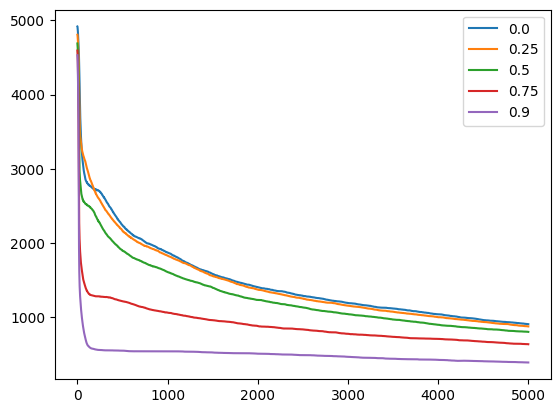

In [62]:

df = results.groupby(['method','corr',"epoch"])['wrong'].mean().reset_index()
df['epoch'] = df['epoch'].astype(int)
for corr in ['0.0','0.25','0.5','0.75',"0.9"]:
    plot_df = df[(df['method']=="erm") & (df['corr']==corr)].sort_values(by="epoch")
    plt.plot(plot_df['epoch'],plot_df['wrong'], label=corr)
    
plt.legend()

In [64]:
df[df['corr']=="0.0"].sort_values(by="epoch")

,method,corr,epoch,wrong
0,erm,0.0,0,4918.000000
1,erm,0.0,1,4915.666667
1112,erm,0.0,2,4904.000000
2223,erm,0.0,3,4896.333333
3334,erm,0.0,4,4876.000000
...,...,...,...,...
4441,erm,0.0,4996,906.666667
4442,erm,0.0,4997,906.333333
4443,erm,0.0,4998,906.333333
4444,erm,0.0,4999,906.333333


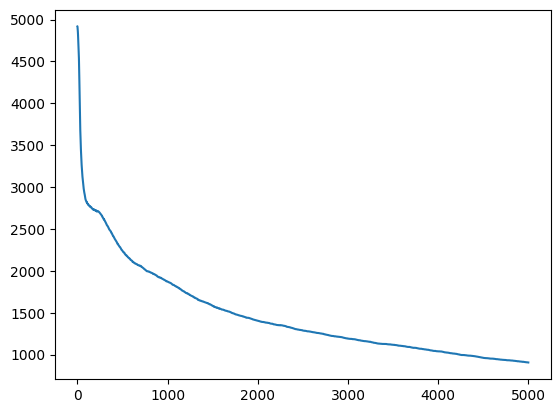

In [59]:
import matplotlib.pyplot as plt
